In [4]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

In [5]:
penguin_data = sns.load_dataset('penguins')
penguin_data.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


In [9]:
penguin_data.shape

(344, 7)

In [10]:
penguin_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


In [16]:
penguin_data.dropna(inplace=True)

In [17]:
penguin_data.shape

(333, 7)

<Axes: xlabel='bill_length_mm', ylabel='Density'>

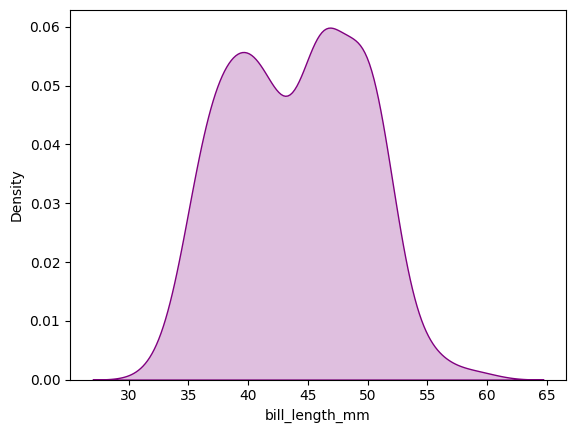

In [25]:
sns.kdeplot(data=penguin_data['bill_length_mm'], fill=True, color='purple')

<Axes: xlabel='bill_length_mm', ylabel='Density'>

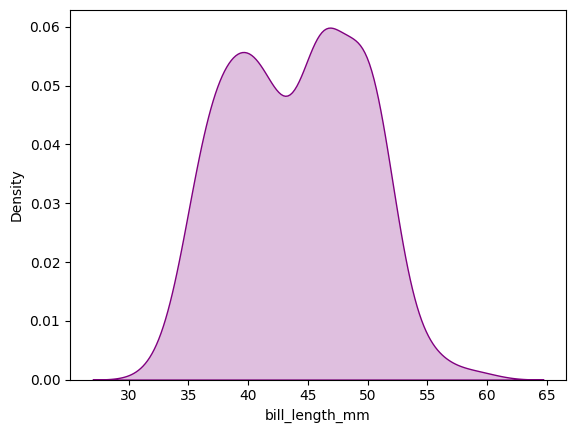

In [26]:
sns.kdeplot(data=penguin_data, x='bill_length_mm', fill=True, color='purple')

In [48]:
mean = round(penguin_data['bill_depth_mm'].mean(), 6)
std = round(penguin_data['bill_depth_mm'].std(),6)
print(f'Mean {mean}')
print(f'Standard Distribution {std}')

Mean 17.164865
Standard Distribution 1.969235


In [49]:
penguin_data['bill_depth_mm']

,bill_depth_mm
0,18.7
1,17.4
2,18.0
4,19.3
5,20.6
...,...
338,13.7
340,14.3
341,15.7
342,14.8


### Lets normalize this data

In [50]:
norm_penguin_data = [ float((x-mean) / std) for x in  penguin_data['bill_depth_mm']]

In [51]:
norm_penguin_data = pd.DataFrame({'bill_depth_mm': norm_penguin_data})

In [56]:
round(norm_penguin_data.mean(),2)

,0
bill_depth_mm,-0.0


In [55]:
round(norm_penguin_data.std(),2)

,0
bill_depth_mm,1.0


### Distribution after Scaling

<Axes: ylabel='Density'>

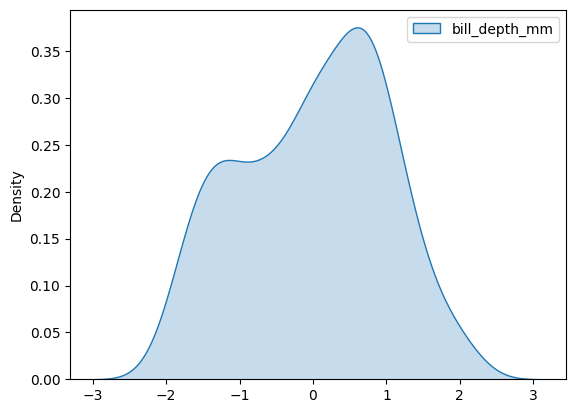

In [57]:
sns.kdeplot(data=norm_penguin_data, fill=True, color='green')

### Scaling with the help of library

In [58]:
from sklearn.preprocessing import StandardScaler

In [59]:
scale = StandardScaler()

In [70]:
penguin_data[['bill_depth_mm']]

,bill_depth_mm
0,18.7
1,17.4
2,18.0
4,19.3
5,20.6
...,...
338,13.7
340,14.3
341,15.7
342,14.8


In [71]:
penguin_data['bill_depth_mm']

,bill_depth_mm
0,18.7
1,17.4
2,18.0
4,19.3
5,20.6
...,...
338,13.7
340,14.3
341,15.7
342,14.8


In [91]:
scaled_bill_length = scale.fit_transform(penguin_data['bill_depth_mm'].values.reshape(-1,1))
print(f'Mean: {round(scaled_bill_length.mean(),2)}')
print(f'Std: {round(scaled_bill_length.std(), 2)}')

Mean: 0.0
Std: 1.0


In [92]:
scaled_bill_length.shape

(333, 1)

In [94]:
pd.DataFrame({'Bill Length (mm)': scaled_bill_length[:, 0]})

,Bill Length (mm)
0,0.780732
1,0.119584
2,0.424729
3,1.085877
4,1.747026
...,...
328,-1.762145
329,-1.457000
330,-0.744994
331,-1.202712


In [96]:
# other ways of doing it are
"""
1. Flatten
2. Squeeze

"""

'\n1. Flatten \n2. Squeeze\n\n'

<Axes: ylabel='Density'>

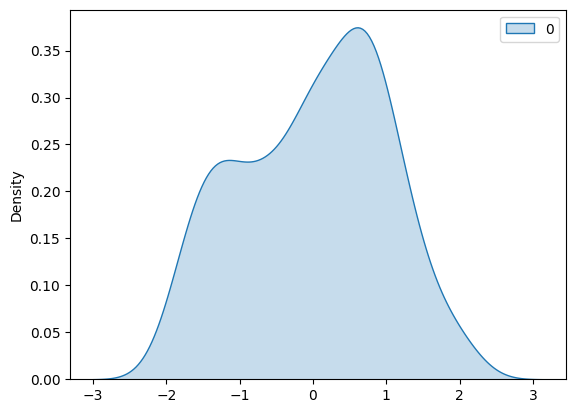

In [98]:
sns.kdeplot(scaled_bill_length, fill=True, color='Blue')